# t-SNE: A Comprehensive Interactive Tutorial

**t-distributed Stochastic Neighbor Embedding (t-SNE)** is a powerful nonlinear dimensionality reduction technique designed to preserve local neighborhood structure when visualizing high-dimensional data in 2D or 3D.

## Learning Objectives

By the end of this notebook, you will:

1. **Understand** why linear methods like PCA fail on nonlinear manifolds
2. **Visualize** the t-SNE objective function and its three-step pipeline (p → q → KL divergence)
3. **Explore** the role of perplexity and kernel choice (Gaussian vs. Student-t)
4. **Observe** how gradient descent optimization shapes embeddings over time
5. **Apply** t-SNE correctly with proper preprocessing and parameter choices
6. **Recognize** common pitfalls and interpret t-SNE plots critically
7. **Compare** t-SNE with alternatives like PCA, MDS, and UMAP

---

## Table of Contents

1. **Motivation & Where t-SNE Fits**
2. **The t-SNE Objective in Plain Language**
3. **Perplexity, Kernels, and the Crowding Problem**
4. **Optimization Details**
5. **How to Use t-SNE in Practice**
6. **Interpretation & Common Pitfalls**
7. **Alternatives & Wrap-Up**
8. **Real Dataset Application**

# 1. Motivation & Where t-SNE Fits

**The Problem:** Many real-world datasets live on low-dimensional **nonlinear manifolds** embedded in high-dimensional space. Linear methods like PCA can only capture variance along straight directions, so they fail to "unfold" curved structures.

**The Solution:** t-SNE preserves **local neighborhood structure** rather than global variance. It keeps similar points close together in the embedding, even when the underlying manifold is curved.

Let's see this in action with synthetic datasets.

## 1.1 Import Required Libraries

In [1]:
# Core numerical and data manipulation
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy

# Dimensionality reduction and machine learning
from sklearn.manifold import TSNE, MDS
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import (make_swiss_roll, make_s_curve, 
                               make_circles, make_blobs, load_digits)
from sklearn.neighbors import NearestNeighbors

# Visualization
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Interactive widgets
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display, HTML, clear_output

# Timing and warnings
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Try to import UMAP (optional, but recommended for section 7)
try:
    import umap
    UMAP_AVAILABLE = True
    print("✓ All libraries imported successfully, including UMAP")
except ImportError:
    UMAP_AVAILABLE = False
    print("✓ All libraries imported successfully")
    print("⚠ UMAP not available. Install with: pip install umap-learn")

# Consistent color scheme throughout the notebook
COLORS = {
    'A': '#e74c3c',  # Red
    'B': '#3498db',  # Blue
    'C': '#2ecc71',  # Green
    'D': '#f39c12',  # Orange
    'E': '#9b59b6',  # Purple
}

✓ All libraries imported successfully, including UMAP


## 1.2 Generate Synthetic Datasets

We'll create several synthetic datasets that highlight when nonlinear methods are necessary:

1. **Swiss Roll**: A 2D manifold rolled in 3D space
2. **S-Curve**: A curved 2D surface in 3D
3. **Concentric Spheres**: Two spheres, one inside the other
4. **Clustered Blobs**: Separated Gaussian clusters (where PCA works fine)

In [2]:
def generate_datasets(n_samples=1000):
    """
    Generate multiple synthetic datasets for comparing PCA and t-SNE.
    
    Returns:
        dict: Dictionary containing dataset name as key and (X, color) tuple as value
    """
    datasets = {}
    
    # 1. Swiss Roll - 2D manifold rolled in 3D
    X_swiss, color_swiss = make_swiss_roll(n_samples=n_samples, noise=0.1, random_state=42)
    datasets['Swiss Roll'] = (X_swiss, color_swiss)
    
    # 2. S-Curve - curved 2D surface in 3D
    X_s_curve, color_s_curve = make_s_curve(n_samples=n_samples, noise=0.1, random_state=42)
    datasets['S-Curve'] = (X_s_curve, color_s_curve)
    
    # 3. Concentric Spheres - two nested spheres
    X_spheres, y_spheres = make_circles(n_samples=n_samples, noise=0.05, factor=0.5, random_state=42)
    # Embed in 3D by adding a third dimension
    X_spheres_3d = np.column_stack([X_spheres, np.zeros(n_samples)])
    datasets['Concentric Circles'] = (X_spheres_3d, y_spheres)
    
    # 4. Clustered Blobs - where PCA works well
    X_blobs, y_blobs = make_blobs(n_samples=n_samples, centers=3, n_features=10, 
                                   cluster_std=1.0, random_state=42)
    datasets['Clustered Blobs'] = (X_blobs, y_blobs)
    
    return datasets

# Generate all datasets
datasets = generate_datasets(n_samples=1000)

print("Generated datasets:")
for name, (X, color) in datasets.items():
    print(f"  {name}: shape {X.shape}")

Generated datasets:
  Swiss Roll: shape (1000, 3)
  S-Curve: shape (1000, 3)
  Concentric Circles: shape (1000, 3)
  Clustered Blobs: shape (1000, 10)


## 1.3 Interactive: PCA vs t-SNE Comparison

Use the widget below to switch between datasets and see how PCA and t-SNE perform on each one.

**What to observe:**
- On the **Swiss Roll** and **S-Curve**, PCA mixes colors because it cannot unfold the curved manifold
- On **Concentric Circles**, PCA fails to separate the two groups
- On **Clustered Blobs**, both methods work reasonably well (linear structure is sufficient)

In [ ]:
def compare_pca_tsne(dataset_name):
    """
    Compare PCA and t-SNE side-by-side for a chosen dataset.
    """
    X, color = datasets[dataset_name]
    
    # Standardize data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply PCA (2 components)
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    # Apply t-SNE (2 components)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, 
                max_iter=1000, learning_rate=200)
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Create figure with 3 subplots
    fig = plt.figure(figsize=(18, 5))
    
    # Original data (if 3D)
    if X.shape[1] == 3:
        ax1 = fig.add_subplot(131, projection='3d')
        scatter1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap='viridis', s=10)
        ax1.set_title(f'{dataset_name} (Original 3D)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('X1')
        ax1.set_ylabel('X2')
        ax1.set_zlabel('X3')
        plt.colorbar(scatter1, ax=ax1, label='True Color/Label')
    else:
        ax1 = fig.add_subplot(131)
        ax1.text(0.5, 0.5, f'{dataset_name}\n(High-dimensional)', 
                ha='center', va='center', fontsize=14)
        ax1.axis('off')
    
    # PCA embedding
    ax2 = fig.add_subplot(132)
    scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap='viridis', s=10)
    ax2.set_title(f'PCA (2D)\nExplained Variance: {pca.explained_variance_ratio_.sum():.1%}', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('PC 1')
    ax2.set_ylabel('PC 2')
    plt.colorbar(scatter2, ax=ax2, label='True Color/Label')
    ax2.grid(True, alpha=0.3)
    
    # t-SNE embedding
    ax3 = fig.add_subplot(133)
    scatter3 = ax3.scatter(X_tsne[:, 0], X_tsne[:, 1], c=color, cmap='viridis', s=10)
    ax3.set_title('t-SNE (2D)\nPreserves Local Neighborhoods', 
                  fontsize=14, fontweight='bold')
    ax3.set_xlabel('t-SNE 1')
    ax3.set_ylabel('t-SNE 2')
    plt.colorbar(scatter3, ax=ax3, label='True Color/Label')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create interactive widget
interact(compare_pca_tsne, dataset_name=list(datasets.keys()));

interactive(children=(Dropdown(description='dataset_name', options=('Swiss Roll', 'S-Curve', 'Concentric Circl…

## 1.4 Key Takeaway

<div style="background-color: #e8f4f8; padding: 15px; border-left: 5px solid #2196F3; border-radius: 5px;">
    
### 🔑 Central Insight

**PCA** preserves **global variance** — it finds the directions of maximum spread in the data. This works well when clusters are linearly separable or when the data lies along straight directions.

**t-SNE** preserves **local neighborhood structure** — it keeps similar points close together in the embedding, even when the underlying manifold is curved. This makes it ideal for visualizing nonlinear structure.

**Rule of Thumb:**
- Use **PCA** when you need interpretable axes, fast computation, or when data structure is roughly linear
- Use **t-SNE** when you want to visualize clusters and local structure in complex, nonlinear data
- t-SNE axes have **no intrinsic meaning** — only relative distances matter

</div>

---

# 2. The t-SNE Objective in Plain Language

## 2.1 The Three-Step Pipeline

t-SNE works by following a simple three-step process:

1. **Compute $p_{ij}$** (high-dimensional similarities): For every pair of points $(i,j)$ in the original high-dimensional space, compute a similarity using a **Gaussian kernel**:

   $$p_{j|i} = \frac{\exp(-||x_i - x_j||^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-||x_i - x_k||^2 / 2\sigma_i^2)}$$
   
   Then symmetrize: $p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$

2. **Compute $q_{ij}$** (low-dimensional similarities): For every pair of embedding points $(i,j)$ in the 2D/3D space, compute similarity using a **Student-t distribution** (heavy-tailed):

   $$q_{ij} = \frac{(1 + ||y_i - y_j||^2)^{-1}}{\sum_{k \neq l} (1 + ||y_k - y_l||^2)^{-1}}$$

3. **Minimize KL divergence**: Adjust the embedding positions $\\{y_i\\}$ to make $q_{ij}$ match $p_{ij}$ as closely as possible:

   $$\text{Cost} = KL(P || Q) = \sum_{i \neq j} p_{ij} \log\frac{p_{ij}}{q_{ij}}$$

The gradient pulls similar points (large $p_{ij}$) together and pushes dissimilar points (small $p_{ij}$) apart.

## 2.2 Step-by-Step Visualization on a Tiny Dataset

Let's see this pipeline in action on a tiny dataset (15 points, 3 clusters in 3D).  We'll compute and visualize each matrix.

Tiny dataset shape: (15, 3)
Cluster labels: [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2]


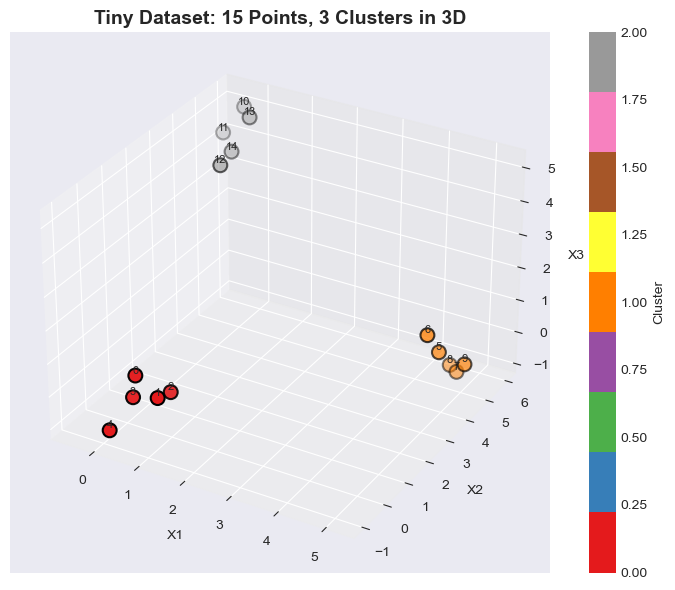

In [5]:
# Create a tiny dataset: 15 points, 3 clusters in 3D
np.random.seed(42)
n_per_cluster = 5
centers = np.array([[0, 0, 0], [5, 5, 0], [0, 5, 5]])
X_tiny = []
y_tiny = []

for i, center in enumerate(centers):
    cluster_points = center + np.random.randn(n_per_cluster, 3) * 0.5
    X_tiny.append(cluster_points)
    y_tiny.extend([i] * n_per_cluster)

X_tiny = np.vstack(X_tiny)
y_tiny = np.array(y_tiny)

print(f"Tiny dataset shape: {X_tiny.shape}")
print(f"Cluster labels: {y_tiny}")

# Visualize the tiny dataset in 3D
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_tiny[:, 0], X_tiny[:, 1], X_tiny[:, 2], 
                     c=y_tiny, cmap='Set1', s=100, edgecolors='k', linewidths=1.5)

# Add point labels
for i in range(len(X_tiny)):
    ax.text(X_tiny[i, 0], X_tiny[i, 1], X_tiny[i, 2], str(i), 
            fontsize=8, ha='center', va='bottom')

ax.set_title('Tiny Dataset: 15 Points, 3 Clusters in 3D', fontsize=14, fontweight='bold')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

In [6]:
def compute_pairwise_distances(X):
    """Compute pairwise Euclidean distance matrix."""
    return squareform(pdist(X, metric='euclidean'))

def compute_p_matrix(X, perplexity=5):
    """
    Compute p_ij similarity matrix using Gaussian kernels.
    Simplified version for educational purposes.
    """
    n = X.shape[0]
    D = compute_pairwise_distances(X)
    
    # Use a fixed sigma for simplicity (in practice, this is tuned per point)
    sigma = np.sqrt(np.mean(D**2) / (2 * np.log(perplexity)))
    
    # Compute conditional probabilities
    P = np.exp(-D**2 / (2 * sigma**2))
    np.fill_diagonal(P, 0)  # p_ii = 0
    P = P / P.sum(axis=1, keepdims=True)  # normalize rows
    
    # Symmetrize
    P = (P + P.T) / (2 * n)
    
    # Avoid numerical issues
    P = np.maximum(P, 1e-12)
    
    return P

def compute_q_matrix(Y):
    """
    Compute q_ij similarity matrix using Student-t distribution (df=1).
    """
    n = Y.shape[0]
    D = compute_pairwise_distances(Y)
    
    # Student-t kernel with df=1
    Q = (1 + D**2)**(-1)
    np.fill_diagonal(Q, 0)  # q_ii = 0
    
    # Normalize
    Q = Q / Q.sum()
    
    # Avoid numerical issues
    Q = np.maximum(Q, 1e-12)
    
    return Q

def compute_kl_cost(P, Q):
    """Compute KL divergence between P and Q matrices."""
    P_flat = P.flatten()
    Q_flat = Q.flatten()
    
    # Element-wise KL contribution
    kl_element = P_flat * np.log(P_flat / Q_flat)
    
    # Total KL cost
    kl_total = np.sum(kl_element)
    
    # Reshape back to matrix form for visualization
    kl_matrix = kl_element.reshape(P.shape)
    
    return kl_total, kl_matrix

# Compute all matrices for the tiny dataset
D_matrix = compute_pairwise_distances(X_tiny)
P_matrix = compute_p_matrix(X_tiny, perplexity=5)

# Apply t-SNE to get embedding
tsne_tiny = TSNE(n_components=2, perplexity=5, random_state=42, max_iter=1000)
Y_tiny = tsne_tiny.fit_transform(X_tiny)

Q_matrix = compute_q_matrix(Y_tiny)
kl_cost, KL_matrix = compute_kl_cost(P_matrix, Q_matrix)

print(f"KL Divergence Cost: {kl_cost:.4f}")

KL Divergence Cost: 0.2680


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


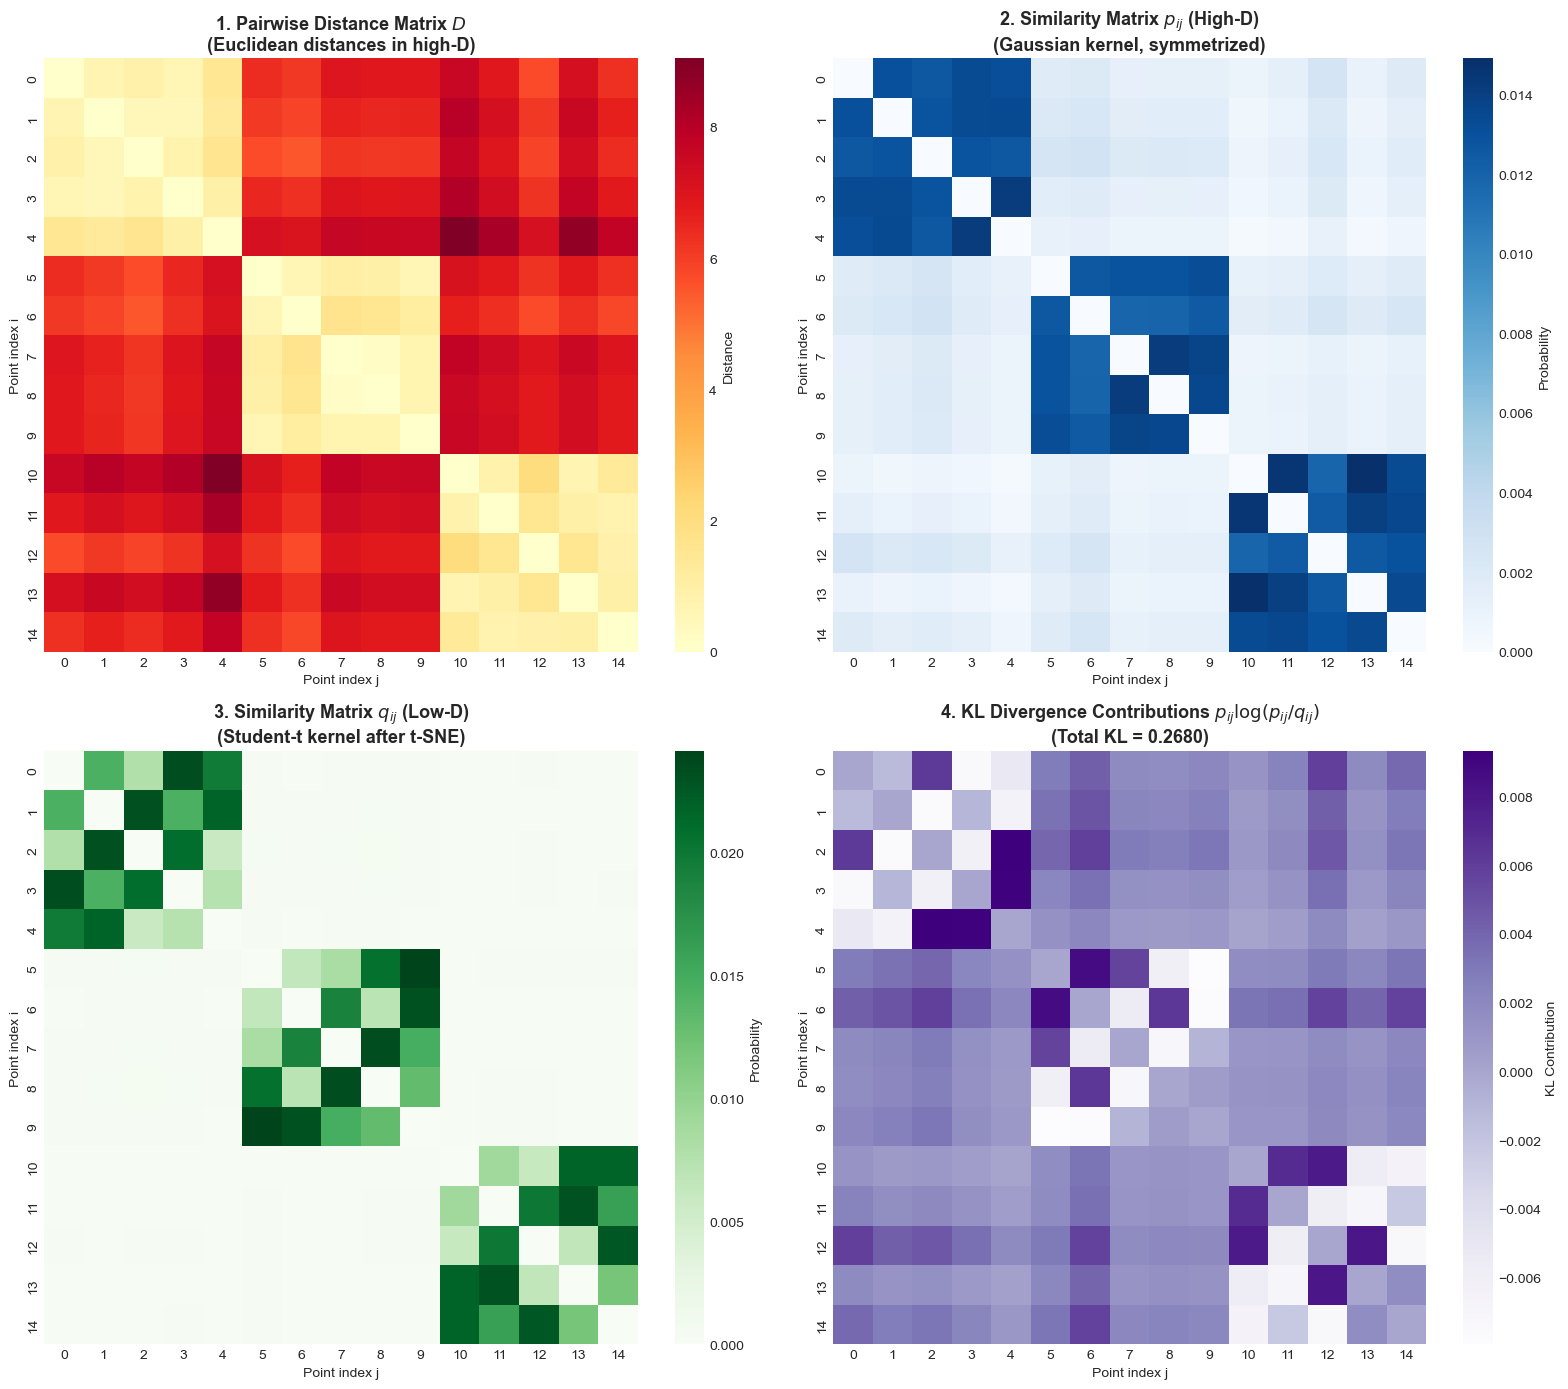

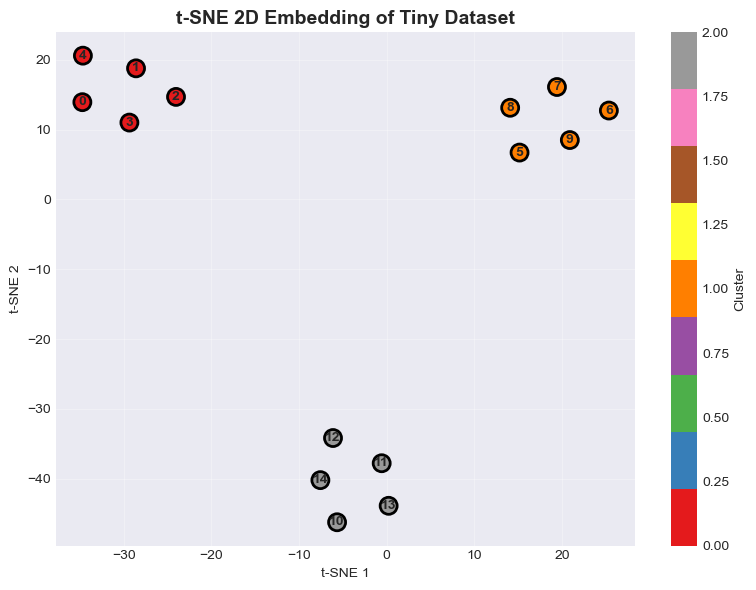

In [7]:
# Visualize all four matrices as heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Distance Matrix
sns.heatmap(D_matrix, annot=False, cmap='YlOrRd', ax=axes[0, 0], cbar_kws={'label': 'Distance'})
axes[0, 0].set_title('1. Pairwise Distance Matrix $D$\n(Euclidean distances in high-D)', 
                     fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Point index j')
axes[0, 0].set_ylabel('Point index i')

# 2. P Matrix (high-D similarities)
sns.heatmap(P_matrix, annot=False, cmap='Blues', ax=axes[0, 1], cbar_kws={'label': 'Probability'})
axes[0, 1].set_title('2. Similarity Matrix $p_{ij}$ (High-D)\n(Gaussian kernel, symmetrized)', 
                     fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Point index j')
axes[0, 1].set_ylabel('Point index i')

# 3. Q Matrix (low-D similarities)
sns.heatmap(Q_matrix, annot=False, cmap='Greens', ax=axes[1, 0], cbar_kws={'label': 'Probability'})
axes[1, 0].set_title('3. Similarity Matrix $q_{ij}$ (Low-D)\n(Student-t kernel after t-SNE)', 
                     fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Point index j')
axes[1, 0].set_ylabel('Point index i')

# 4. KL Contribution Matrix
sns.heatmap(KL_matrix, annot=False, cmap='Purples', ax=axes[1, 1], 
           cbar_kws={'label': 'KL Contribution'})
axes[1, 1].set_title(f'4. KL Divergence Contributions $p_{{ij}} \log(p_{{ij}}/q_{{ij}})$\n(Total KL = {kl_cost:.4f})', 
                     fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Point index j')
axes[1, 1].set_ylabel('Point index i')

plt.tight_layout()
plt.show()

# Also show the 2D embedding
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
scatter = ax.scatter(Y_tiny[:, 0], Y_tiny[:, 1], c=y_tiny, cmap='Set1', 
                    s=150, edgecolors='k', linewidths=2)

# Add point labels
for i in range(len(Y_tiny)):
    ax.text(Y_tiny[i, 0], Y_tiny[i, 1], str(i), 
           fontsize=10, ha='center', va='center', fontweight='bold')

ax.set_title('t-SNE 2D Embedding of Tiny Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

---

# 3. Perplexity, Kernels, and the Crowding Problem

## 3.1 What is Perplexity?

**Perplexity** is roughly interpreted as the effective number of nearest neighbors that t-SNE considers when building the high-dimensional probability distribution.

- **Low perplexity** (e.g., 5-15): Focuses on very local structure, can create fragmented clusters
- **Moderate perplexity** (e.g., 30-50): **Recommended default** — balances local and global structure  
- **High perplexity** (e.g., 100+): Considers more global relationships, can merge distinct clusters

The perplexity controls the bandwidth $\sigma_i$ of the Gaussian kernel for each point $i$. t-SNE automatically adjusts $\sigma_i$ so that the entropy of $p_{j|i}$ matches the target perplexity.

## 3.2 Interactive: Perplexity Explorer

Use the slider to explore how different perplexity values affect the t-SNE embedding of the Swiss Roll dataset.

**What to observe:**
- **Low perplexity**: Clusters fragment into many small pieces
- **Moderate perplexity**: Good balance, smooth unrolling
- **High perplexity**: Clusters may merge, losing some local detail

In [8]:
# Use Swiss Roll for perplexity exploration
X_swiss, color_swiss = datasets['Swiss Roll']
X_swiss_scaled = StandardScaler().fit_transform(X_swiss)

def explore_perplexity(perplexity):
    """Run t-SNE with different perplexity values."""
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, 
                max_iter=1000, learning_rate=200)
    X_embedded = tsne.fit_transform(X_swiss_scaled)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Original 3D
    ax1 = axes[0] = plt.subplot(121, projection='3d')
    scatter1 = ax1.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], 
                          c=color_swiss, cmap='viridis', s=10)
    ax1.set_title('Swiss Roll (Original 3D)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('X1')
    ax1.set_ylabel('X2')
    ax1.set_zlabel('X3')
    plt.colorbar(scatter1, ax=ax1)
    
    # t-SNE embedding with selected perplexity
    ax2 = axes[1]
    scatter2 = ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], 
                          c=color_swiss, cmap='viridis', s=10)
    ax2.set_title(f't-SNE (Perplexity = {perplexity})', fontsize=14, fontweight='bold')
    ax2.set_xlabel('t-SNE 1')
    ax2.set_ylabel('t-SNE 2')
    ax2.grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=ax2)
    
    plt.tight_layout()
    plt.show()

# Create interactive slider
interact(explore_perplexity, perplexity=widgets.IntSlider(min=2, max=100, step=5, value=30, 
                                                           description='Perplexity:'));

# Compute a default embedding (perplexity=30) for use in later cells
print("Computing default Swiss Roll embedding (perplexity=30) for Section 6...")
X_embedded = TSNE(n_components=2, perplexity=30, random_state=42, 
                  max_iter=1000, learning_rate=200).fit_transform(X_swiss_scaled)
print("✓ Default embedding ready")

interactive(children=(IntSlider(value=30, description='Perplexity:', min=2, step=5), Output()), _dom_classes=(…

Computing default Swiss Roll embedding (perplexity=30) for Section 6...
✓ Default embedding ready


## 3.3 The Crowding Problem and Why We Use Student-t

**The Problem:** In high dimensions, there's more "room" for points to spread out. When we project to 2D/3D, we need to squeeze many moderate distances into a small space. If we use a Gaussian kernel in the embedding space (original SNE), distant points get crushed into the center — this is called the **crowding problem**.

**The Solution:** t-SNE uses a **Student-t distribution** (heavy-tailed) in the low-dimensional space instead of a Gaussian. The heavy tail allows moderate distances to be represented more faithfully without cramming everything together.

Let's visualize the difference between these kernels.

In [9]:
def plot_kernel_comparison(df=1):
    """
    Compare Gaussian and Student-t kernels as a function of distance.
    
    Parameters:
        df: Degrees of freedom for Student-t (default 1)
    """
    distances = np.linspace(0, 5, 1000)
    
    # Gaussian kernel: exp(-d^2 / 2)
    gaussian_kernel = np.exp(-distances**2 / 2)
    
    # Student-t kernel: (1 + d^2 / df)^(-(df+1)/2)
    # For df=1 (Cauchy), this simplifies to: (1 + d^2)^(-1)
    student_t_kernel = (1 + distances**2 / df)**(-(df + 1) / 2)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Linear scale
    ax1 = axes[0]
    ax1.plot(distances, gaussian_kernel, label='Gaussian', linewidth=2, color='blue')
    ax1.plot(distances, student_t_kernel, label=f'Student-t (df={df})', linewidth=2, color='red')
    ax1.set_xlabel('Distance d', fontsize=12)
    ax1.set_ylabel('Kernel Value', fontsize=12)
    ax1.set_title('Kernel Comparison (Linear Scale)', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Log scale to emphasize heavy tail
    ax2 = axes[1]
    ax2.semilogy(distances, gaussian_kernel, label='Gaussian', linewidth=2, color='blue')
    ax2.semilogy(distances, student_t_kernel, label=f'Student-t (df={df})', linewidth=2, color='red')
    ax2.set_xlabel('Distance d', fontsize=12)
    ax2.set_ylabel('Kernel Value (log scale)', fontsize=12)
    ax2.set_title('Kernel Comparison (Log Scale) — Heavy Tail Visible', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3, which='both')
    
    # Add annotation
    ax2.annotate('Heavy tail: Student-t decays\nmuch slower than Gaussian', 
                xy=(3.5, student_t_kernel[np.argmin(np.abs(distances - 3.5))]),
                xytext=(2.5, 1e-2), fontsize=11,
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Interactive widget for degrees of freedom
interact(plot_kernel_comparison, 
        df=widgets.IntSlider(min=1, max=10, step=1, value=1, 
                            description='df (Student-t):'));

interactive(children=(IntSlider(value=1, description='df (Student-t):', max=10, min=1), Output()), _dom_classe…

---

# 4. Optimization Details

## 4.1 How Gradient Descent Shapes the Embedding

t-SNE minimizes the KL divergence using gradient descent. The gradient has an intuitive interpretation:

- **Attractive forces**: Pairs with large $p_{ij}$ (similar in high-D) are pulled together
- **Repulsive forces**: Pairs with small $p_{ij}$ (dissimilar in high-D) push each other away

The optimization starts from a random (or PCA) initialization and iteratively adjusts point positions to reduce the KL cost.

### Key Optimization Tricks

1. **Early exaggeration** (first ~250 iterations): Multiply all $p_{ij}$ by 4–12 to create tight clusters early, then fine-tune
2. **Momentum** (gradient descent with inertia): Speeds up convergence and avoids local minima
3. **Learning rate**: Controls step size — too small is slow, too large causes explosion

## 4.2 Interactive: Learning Rate Explorer

The learning rate controls the step size in gradient descent. Let's see how different values affect the final embedding.

**What to observe:**
- **Too small** (1-10): Very slow convergence, may not separate clusters  
- **Just right** (100-500): Good cluster separation and structure
- **Too large** (1000+): Unstable, may explode or oscillate

In [10]:
# Use a moderate-sized blob dataset for faster computation
X_lr, y_lr = make_blobs(n_samples=300, centers=4, n_features=20, random_state=42)
X_lr_scaled = StandardScaler().fit_transform(X_lr)

def explore_learning_rate(learning_rate):
    """Run t-SNE with different learning rates."""
    try:
        tsne = TSNE(n_components=2, perplexity=30, random_state=42, 
                   max_iter=1000, learning_rate=learning_rate)
        X_embedded = tsne.fit_transform(X_lr_scaled)
        
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        scatter = ax.scatter(X_embedded[:, 0], X_embedded[:, 1], 
                           c=y_lr, cmap='Set1', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
        ax.set_title(f't-SNE with Learning Rate = {learning_rate}', fontsize=14, fontweight='bold')
        ax.set_xlabel('t-SNE 1', fontsize=12)
        ax.set_ylabel('t-SNE 2', fontsize=12)
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='Cluster')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"⚠ Learning rate {learning_rate} failed: {e}")
        print("Try a different value!")

# Create dropdown for learning rate selection
interact(explore_learning_rate, 
        learning_rate=widgets.Dropdown(options=[1, 10, 50, 200, 500, 1000, 5000], 
                                      value=200, 
                                      description='Learning Rate:'));

interactive(children=(Dropdown(description='Learning Rate:', index=3, options=(1, 10, 50, 200, 500, 1000, 5000…

---

# 5. How to Use t-SNE in Practice

## 5.1 Full Pipeline Template

Here's a complete, copy-paste-ready code template for applying t-SNE to your own data.

Data shape: (1797, 64)
Number of features: 64
Number of samples: 1797
✓ Data scaled (mean=0, std=1)
✓ PCA applied: 64 → 50 dimensions
  Explained variance: 98.3%

⏳ Running t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1797 samples in 0.000s...
[t-SNE] Computed neighbors for 1797 samples in 0.046s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1797
[t-SNE] Computed conditional probabilities for sample 1797 / 1797
[t-SNE] Mean sigma: 2.344951
[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.629311
[t-SNE] KL divergence after 1000 iterations: 0.821171
✓ t-SNE completed!


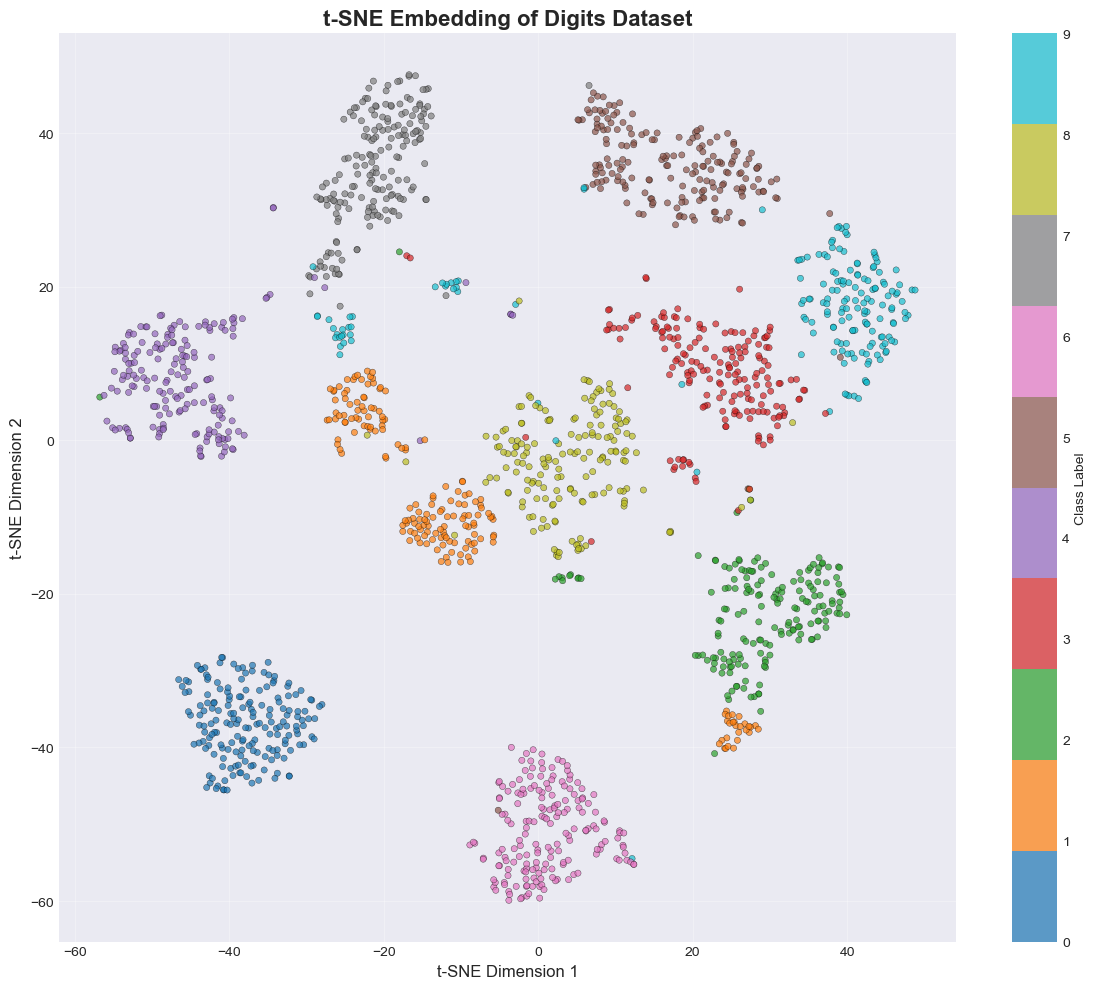


✅ Pipeline complete! See plot above.


In [11]:
"""
=========================================
COMPLETE t-SNE PIPELINE TEMPLATE
=========================================
Copy this code block for your own projects!
"""

# Step 1: Load your data
# X should be a NumPy array or DataFrame with shape (n_samples, n_features)
# y should be labels (if available) for visualization
# Example: X, y = load_your_data()

# For demonstration, we'll use the digits dataset
from sklearn.datasets import load_digits
data = load_digits()
X = data.data  # Shape: (1797, 64)
y = data.target  # Digit labels 0-9

print(f"Data shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")

# Step 2: Handle missing values (if any)
# X = X.fillna(X.mean())  # For DataFrames
# X = np.nan_to_num(X)    # For NumPy arrays

# Step 3: Standardize features (IMPORTANT!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✓ Data scaled (mean=0, std=1)")

# Step 4: Optional PCA preprocessing (recommended for high-D data)
# Reduces computational cost and can remove noise
n_pca_components = 50  # Use <= 50 for most cases
if X.shape[1] > n_pca_components:
    pca = PCA(n_components=n_pca_components, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    print(f"✓ PCA applied: {X.shape[1]} → {n_pca_components} dimensions")
    print(f"  Explained variance: {pca.explained_variance_ratio_.sum():.1%}")
else:
    X_pca = X_scaled
    print("✓ Skipping PCA (already low-dimensional)")

# Step 5: Apply t-SNE
print("\n⏳ Running t-SNE...")
tsne = TSNE(
    n_components=2,        # 2D embedding (or 3 for 3D)
    perplexity=30,         # 30-50 is usually good
    learning_rate=200,     # 'auto' or 100-500
    max_iter=1000,         # Default 1000, increase if not converged
    random_state=42,       # For reproducibility
    init='pca',            # 'pca' or 'random' initialization
    verbose=1              # Show progress
)

X_embedded = tsne.fit_transform(X_pca)
print("✓ t-SNE completed!")

# Step 6: Visualize the embedding
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], 
                     c=y, cmap='tab10', s=20, alpha=0.7, edgecolors='k', linewidths=0.3)
plt.colorbar(scatter, label='Class Label')
plt.title('t-SNE Embedding of Digits Dataset', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✅ Pipeline complete! See plot above.")
print("="*60)

## 5.2 Why Feature Scaling Matters

t-SNE is based on Euclidean distances. If one feature has a much larger scale than others (e.g., income in thousands vs. age in decades), it will dominate the distance calculations and distort the embedding.

**Always standardize your features before t-SNE!**

In [12]:
# Create a dataset where one feature dominates
np.random.seed(42)
X_unbalanced, y_unbalanced = make_blobs(n_samples=500, centers=3, n_features=5, random_state=42)

# Artificially scale one feature to be 100x larger
X_unbalanced[:, 0] *= 100

def compare_scaling(use_scaling):
    """Compare t-SNE with and without feature scaling."""
    if use_scaling:
        X_processed = StandardScaler().fit_transform(X_unbalanced)
        title_suffix = "(Scaled)"
    else:
        X_processed = X_unbalanced
        title_suffix = "(Unscaled)"
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, learning_rate=200)
    X_embedded = tsne.fit_transform(X_processed)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    scatter = ax.scatter(X_embedded[:, 0], X_embedded[:, 1], 
                        c=y_unbalanced, cmap='Set1', s=50, alpha=0.7, edgecolors='k', linewidths=0.5)
    ax.set_title(f't-SNE Embedding {title_suffix}', fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE 1', fontsize=12)
    ax.set_ylabel('t-SNE 2', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='True Cluster')
    
    if not use_scaling:
        ax.text(0.5, 0.95, '⚠ Feature 1 is 100x larger — dominates distances!', 
               transform=ax.transAxes, ha='center', va='top',
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7), fontsize=11)
    else:
        ax.text(0.5, 0.95, '✓ All features standardized — balanced embedding', 
               transform=ax.transAxes, ha='center', va='top',
               bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7), fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Interactive toggle
interact(compare_scaling, 
        use_scaling=widgets.ToggleButtons(options=[('Unscaled', False), ('Scaled ✓', True)], 
                                         value=False, button_style=''));

interactive(children=(ToggleButtons(description='use_scaling', options=(('Unscaled', False), ('Scaled ✓', True…

---

# 6. Interpretation & Common Pitfalls

## ⚠️ Critical Skills: How to Read t-SNE Plots

t-SNE is an excellent visualization tool, but it can be misleading if you don't understand its limitations. Let's explore the most common pitfalls.

## 6.1 Pitfall #1: Axes are Meaningless

**The Problem:** Unlike PCA, t-SNE axes have **no intrinsic meaning**. The embedding can be rotated, reflected, or translated arbitrarily. Even with the same random seed, small numerical differences can lead to different orientations.

**What to trust:** Relative positions and cluster structure, **not** absolute coordinates or axis directions.

Let's run t-SNE three times with different seeds to see this effect.

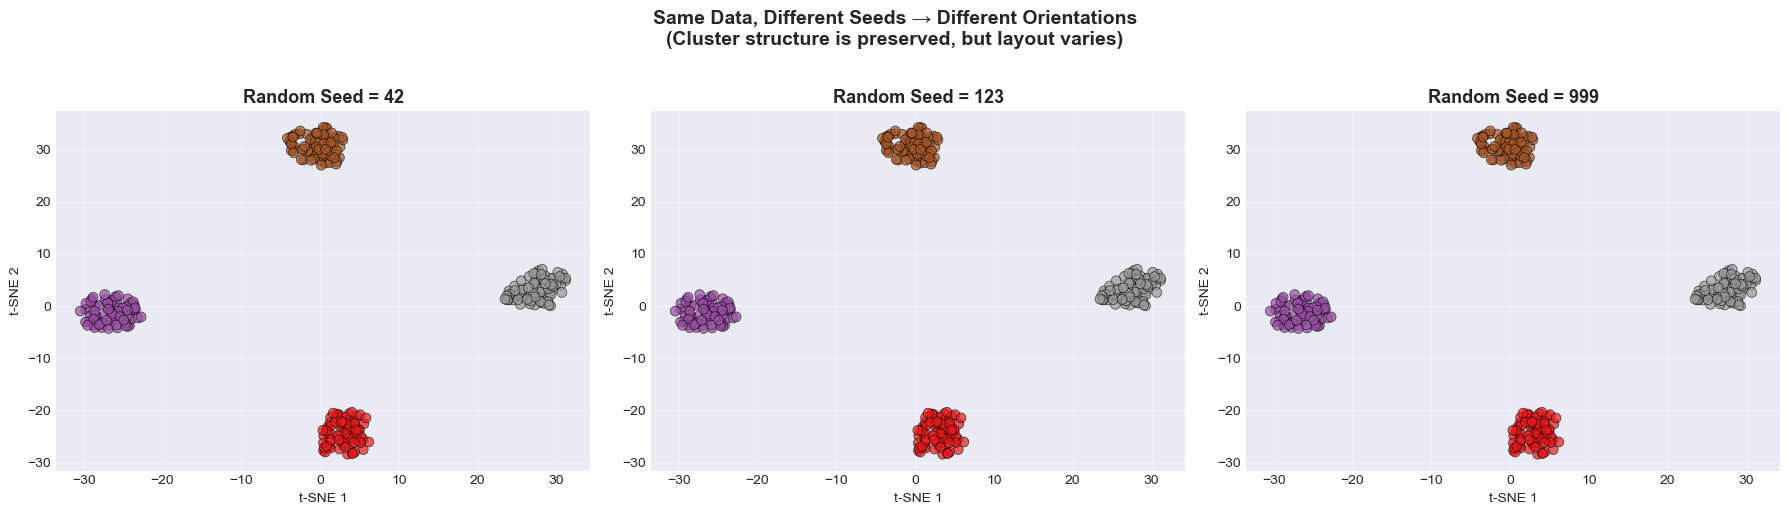

✓ Notice: The clusters are preserved, but rotated/reflected differently in each run.


In [16]:
# Use a moderate dataset
X_pitfall, y_pitfall = make_blobs(n_samples=300, centers=4, n_features=10, random_state=42)
X_pitfall_scaled = StandardScaler().fit_transform(X_pitfall)

# Run t-SNE with three different random seeds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
seeds = [42, 123, 999]

for idx, seed in enumerate(seeds):
    tsne = TSNE(n_components=2, perplexity=30, random_state=seed, max_iter=1000, learning_rate=200)
    X_embedded_seed = tsne.fit_transform(X_pitfall_scaled)
    
    scatter = axes[idx].scatter(X_embedded_seed[:, 0], X_embedded_seed[:, 1], 
                               c=y_pitfall, cmap='Set1', s=50, alpha=0.7, 
                               edgecolors='k', linewidths=0.5)
    axes[idx].set_title(f'Random Seed = {seed}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Same Data, Different Seeds → Different Orientations\n' + 
            '(Cluster structure is preserved, but layout varies)', 
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Notice: The clusters are preserved, but rotated/reflected differently in each run.")

## 6.2 Pitfall #2: Global Distances Are NOT Preserved

**The Problem:** t-SNE preserves **local** neighborhood structure, not **global** distances. The distance between two clusters in the embedding does **not** reflect their true distance in high-dimensional space.

**Example:** Two clusters that are far apart in high-D may appear close in the t-SNE plot (or vice versa).

Let's create three clusters where A and B are close in the original space, and C is far away, then see what t-SNE does.

True inter-cluster centroid distances (high-D):
  A—B: 6.32
  A—C: 31.62
  B—C: 25.30

Inter-cluster centroid distances in t-SNE embedding:
  A—B: 42.11
  A—C: 37.13
  B—C: 35.98


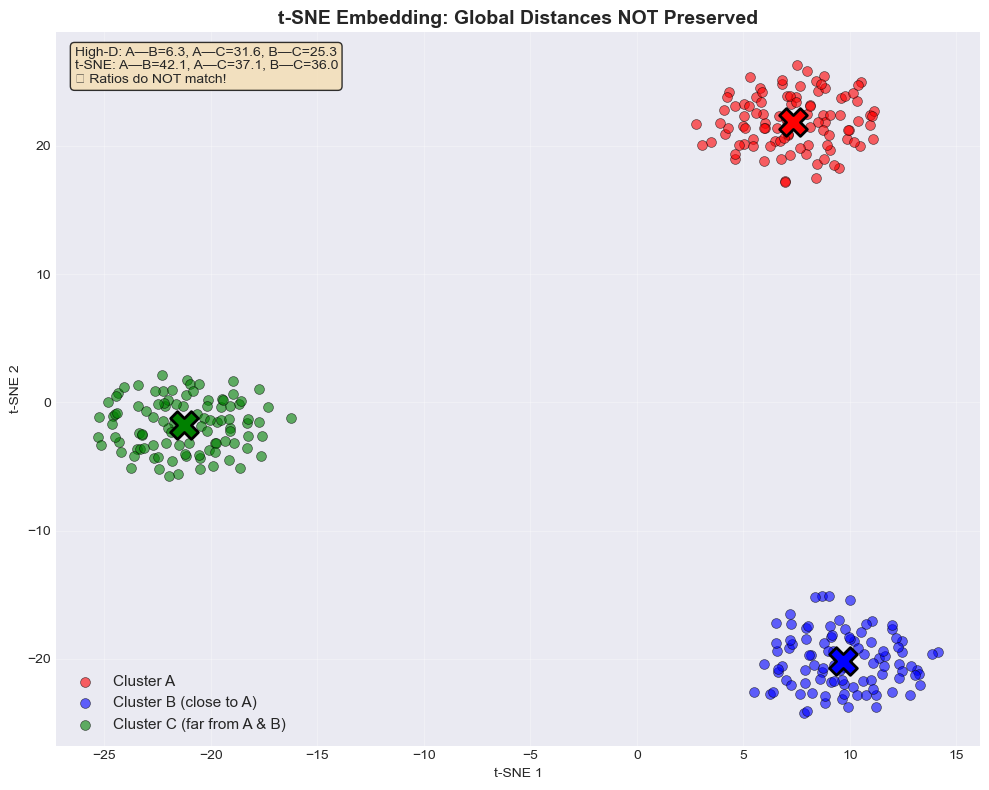

In [17]:
# Create three clusters with controlled center distances
np.random.seed(42)
cluster_A = np.random.randn(100, 10) * 0.5 + np.array([0]*10)     # Center at origin
cluster_B = np.random.randn(100, 10) * 0.5 + np.array([2]*10)     # Close to A (distance ≈ 2√10 ≈ 6.3)
cluster_C = np.random.randn(100, 10) * 0.5 + np.array([10]*10)    # Far from A & B (distance ≈ 31.6)

X_global = np.vstack([cluster_A, cluster_B, cluster_C])
y_global = np.array([0]*100 + [1]*100 + [2]*100)

# Compute true inter-cluster distances in high-D
centers = np.array([[0]*10, [2]*10, [10]*10])
dist_AB_true = np.linalg.norm(centers[0] - centers[1])
dist_AC_true = np.linalg.norm(centers[0] - centers[2])
dist_BC_true = np.linalg.norm(centers[1] - centers[2])

print("True inter-cluster centroid distances (high-D):")
print(f"  A—B: {dist_AB_true:.2f}")
print(f"  A—C: {dist_AC_true:.2f}")
print(f"  B—C: {dist_BC_true:.2f}")

# Apply t-SNE
X_global_scaled = StandardScaler().fit_transform(X_global)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, learning_rate=200)
X_embedded_global = tsne.fit_transform(X_global_scaled)

# Compute inter-cluster distances in t-SNE embedding
centers_embedded = np.array([
    X_embedded_global[y_global == 0].mean(axis=0),
    X_embedded_global[y_global == 1].mean(axis=0),
    X_embedded_global[y_global == 2].mean(axis=0)
])
dist_AB_tsne = np.linalg.norm(centers_embedded[0] - centers_embedded[1])
dist_AC_tsne = np.linalg.norm(centers_embedded[0] - centers_embedded[2])
dist_BC_tsne = np.linalg.norm(centers_embedded[1] - centers_embedded[2])

print("\nInter-cluster centroid distances in t-SNE embedding:")
print(f"  A—B: {dist_AB_tsne:.2f}")
print(f"  A—C: {dist_AC_tsne:.2f}")
print(f"  B—C: {dist_BC_tsne:.2f}")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
colors = ['red', 'blue', 'green']
labels = ['Cluster A', 'Cluster B (close to A)', 'Cluster C (far from A & B)']

for i in range(3):
    mask = y_global == i
    ax.scatter(X_embedded_global[mask, 0], X_embedded_global[mask, 1], 
              c=colors[i], label=labels[i], s=50, alpha=0.6, edgecolors='k', linewidths=0.5)
    
    # Mark centroids
    ax.scatter(centers_embedded[i, 0], centers_embedded[i, 1], 
              c=colors[i], s=400, marker='X', edgecolors='black', linewidths=2)

ax.set_title('t-SNE Embedding: Global Distances NOT Preserved', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add text box with comparison
textstr = f'High-D: A—B={dist_AB_true:.1f}, A—C={dist_AC_true:.1f}, B—C={dist_BC_true:.1f}\n' \
          f't-SNE: A—B={dist_AB_tsne:.1f}, A—C={dist_AC_tsne:.1f}, B—C={dist_BC_tsne:.1f}\n' \
          f'⚠ Ratios do NOT match!'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

## 6.3 Sanity Check: k-NN Overlap Metric

**Question:** How well does the t-SNE embedding preserve neighborhood structure?

**Answer:** We can quantify this by comparing k-nearest neighbors in high-D vs. the embedding using **Jaccard similarity**.

For each point, we compute:
$$\text{Jaccard}(i) = \frac{|\text{neighbors}_{\text{high-D}}(i) \cap \text{neighbors}_{\text{embedding}}(i)|}{|\text{neighbors}_{\text{high-D}}(i) \cup \text{neighbors}_{\text{embedding}}(i)|}$$

A score close to 1 means the embedding preserves local structure well.

Ensuring Swiss Roll embedding for k-NN analysis...
✓ X_swiss_scaled: (1000, 3)  |  X_embedded: (1000, 2)
Mean k-NN overlap (Jaccard): 0.764
Median k-NN overlap: 0.765
Min overlap: 0.250
Max overlap: 1.000


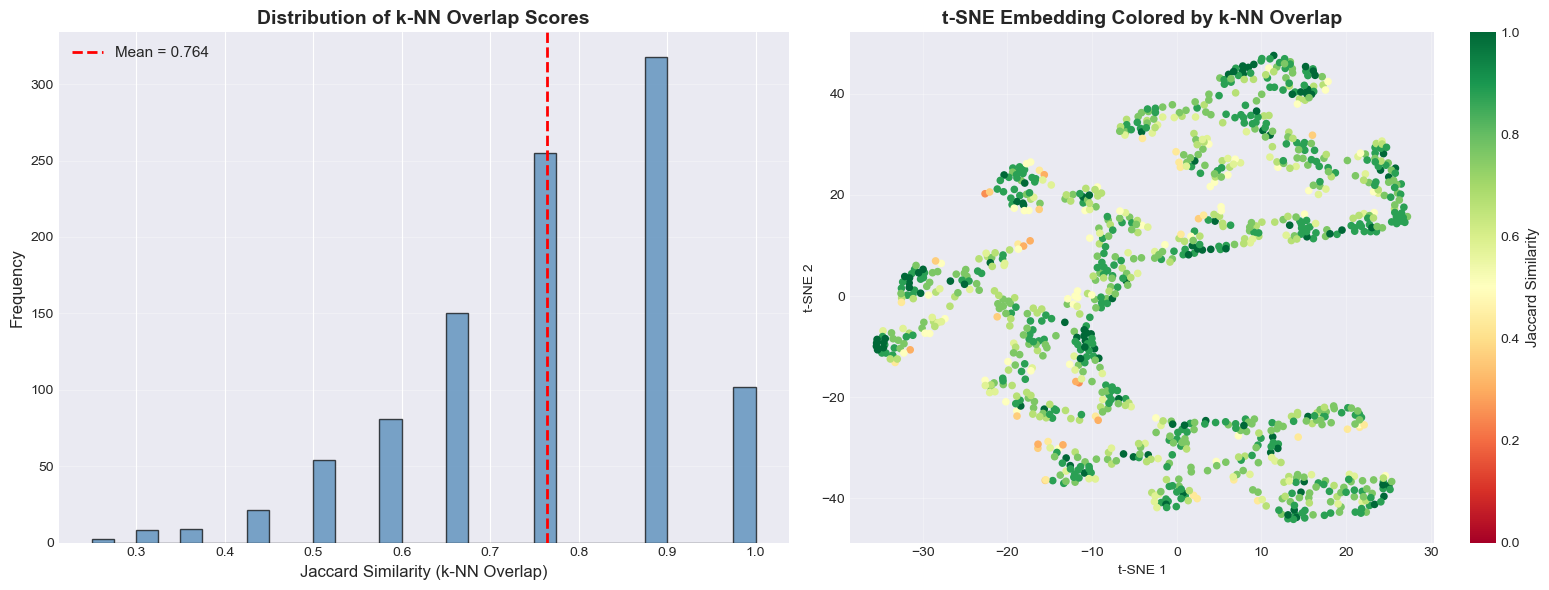


✓ Interpretation: Higher Jaccard scores (green) indicate better local neighborhood preservation.


In [18]:
# Recompute Swiss Roll embedding to ensure correct pairing with X_swiss_scaled
# (earlier cells may have overwritten the global X_embedded variable)
print("Ensuring Swiss Roll embedding for k-NN analysis...")
X_embedded = TSNE(n_components=2, perplexity=30, random_state=42,
                  max_iter=1000, learning_rate=200).fit_transform(X_swiss_scaled)
print(f"✓ X_swiss_scaled: {X_swiss_scaled.shape}  |  X_embedded: {X_embedded.shape}")

def compute_knn_overlap(X_high, X_low, k=15):
    """
    Compute k-NN overlap (Jaccard similarity) between high-D and low-D spaces.
    
    Parameters:
        X_high: Original high-dimensional data
        X_low: Low-dimensional embedding
        k: Number of nearest neighbors to consider
    
    Returns:
        jaccard_scores: Array of Jaccard scores for each point
    """
    n_samples = X_high.shape[0]
    
    # Fit k-NN in high-D space
    nbrs_high = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_high)
    _, indices_high = nbrs_high.kneighbors(X_high)
    indices_high = indices_high[:, 1:]  # Exclude self
    
    # Fit k-NN in low-D space
    nbrs_low = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_low)
    _, indices_low = nbrs_low.kneighbors(X_low)
    indices_low = indices_low[:, 1:]  # Exclude self
    
    # Compute Jaccard similarity for each point
    jaccard_scores = []
    for i in range(n_samples):
        neighbors_high = set(indices_high[i])
        neighbors_low = set(indices_low[i])
        
        intersection = len(neighbors_high & neighbors_low)
        union = len(neighbors_high | neighbors_low)
        
        jaccard = intersection / union if union > 0 else 0
        jaccard_scores.append(jaccard)
    
    return np.array(jaccard_scores)

# Compute overlap for our Swiss Roll example
jaccard_scores = compute_knn_overlap(X_swiss_scaled, X_embedded, k=15)

print(f"Mean k-NN overlap (Jaccard): {jaccard_scores.mean():.3f}")
print(f"Median k-NN overlap: {np.median(jaccard_scores):.3f}")
print(f"Min overlap: {jaccard_scores.min():.3f}")
print(f"Max overlap: {jaccard_scores.max():.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of Jaccard scores
axes[0].hist(jaccard_scores, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(jaccard_scores.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean = {jaccard_scores.mean():.3f}')
axes[0].set_xlabel('Jaccard Similarity (k-NN Overlap)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of k-NN Overlap Scores', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# t-SNE embedding colored by Jaccard score
scatter = axes[1].scatter(X_embedded[:, 0], X_embedded[:, 1], 
                         c=jaccard_scores, cmap='RdYlGn', s=20, vmin=0, vmax=1)
axes[1].set_title('t-SNE Embedding Colored by k-NN Overlap', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Jaccard Similarity', fontsize=11)

plt.tight_layout()
plt.show()

print("\n✓ Interpretation: Higher Jaccard scores (green) indicate better local neighborhood preservation.")


---

# 7. Alternatives & Wrap-Up

## 7.1 Method Comparison Dashboard

t-SNE is not the only dimensionality reduction method. Let's compare it with other popular techniques:

1. **PCA**: Linear, fast, interpretable axes, preserves global variance
2. **MDS (Multidimensional Scaling)**: Preserves pairwise distances, can be slow
3. **t-SNE**: Preserves local neighborhoods, nonlinear, good for visualization
4. **UMAP**: Similar to t-SNE but faster and can preserve more global structure

Use the dropdown to switch between datasets and see how each method performs.

In [16]:
def compare_methods(dataset_name):
    """Compare PCA, MDS, t-SNE, and UMAP on a chosen dataset."""
    X, color = datasets[dataset_name]
    X_scaled = StandardScaler().fit_transform(X)
    
    # Apply all methods
    print(f"Computing embeddings for {dataset_name}...")
    
    # PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    # MDS
    mds = MDS(n_components=2, random_state=42, n_init=1, max_iter=300)
    X_mds = mds.fit_transform(X_scaled)
    
    # t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, learning_rate=200)
    X_tsne = tsne.fit_transform(X_scaled)
    
    # UMAP (if available)
    if UMAP_AVAILABLE:
        umap_model = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
        X_umap = umap_model.fit_transform(X_scaled)
        n_methods = 4
        method_names = ['PCA', 'MDS', 't-SNE', 'UMAP']
        embeddings = [X_pca, X_mds, X_tsne, X_umap]
    else:
        n_methods = 3
        method_names = ['PCA', 'MDS', 't-SNE']
        embeddings = [X_pca, X_mds, X_tsne]
    
    # Plot all methods
    fig, axes = plt.subplots(1, n_methods, figsize=(n_methods * 5, 5))
    if n_methods == 1:
        axes = [axes]
    
    for idx, (name, X_emb) in enumerate(zip(method_names, embeddings)):
        scatter = axes[idx].scatter(X_emb[:, 0], X_emb[:, 1], c=color, cmap='viridis', 
                                   s=20, alpha=0.7, edgecolors='k', linewidths=0.3)
        axes[idx].set_title(name, fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Dimension 1')
        axes[idx].set_ylabel('Dimension 2')
        axes[idx].grid(True, alpha=0.3)
    
    plt.suptitle(f'Method Comparison: {dataset_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Interactive dropdown
interact(compare_methods, dataset_name=list(datasets.keys()));

interactive(children=(Dropdown(description='dataset_name', options=('Swiss Roll', 'S-Curve', 'Concentric Circl…

## 7.2 UMAP Parameter Explorer

If UMAP is available, we can explore its two main parameters:
- **n_neighbors**: Similar to perplexity in t-SNE (controls local vs. global structure)
- **min_dist**: Minimum distance between points in the embedding (controls tightness)

In [17]:
if UMAP_AVAILABLE:
    def explore_umap_params(n_neighbors, min_dist):
        """Explore UMAP parameters."""
        umap_model = umap.UMAP(n_components=2, random_state=42, 
                              n_neighbors=n_neighbors, min_dist=min_dist)
        X_umap = umap_model.fit_transform(X_swiss_scaled)
        
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        scatter = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=color_swiss, 
                           cmap='viridis', s=20, alpha=0.7)
        ax.set_title(f'UMAP: n_neighbors={n_neighbors}, min_dist={min_dist:.2f}', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax)
        plt.tight_layout()
        plt.show()
    
    # Interactive sliders
    interact(explore_umap_params, 
            n_neighbors=widgets.IntSlider(min=5, max=100, step=5, value=15, 
                                         description='n_neighbors:'),
            min_dist=widgets.FloatSlider(min=0.0, max=1.0, step=0.1, value=0.1, 
                                        description='min_dist:'));
else:
    print("⚠ UMAP not installed. Install with: pip install umap-learn")

⚠ UMAP not installed. Install with: pip install umap-learn


## 7.3 Summary Quiz: Test Your Understanding

Test your knowledge with these interactive questions!

In [ ]:
# Create interactive quiz
questions = [
    {
        'question': 'Q1: True or False: The distance between two clusters in a t-SNE plot reflects their true distance in high-dimensional space.',
        'options': ['True', 'False'],
        'correct': 'False',
        'explanation': 'False! t-SNE preserves LOCAL neighborhoods, not GLOBAL distances. Inter-cluster distances are not meaningful.'
    },
    {
        'question': 'Q2: What does perplexity control in t-SNE?',
        'options': ['The learning rate', 'The effective number of nearest neighbors', 'The number of iterations', 'The random seed'],
        'correct': 'The effective number of nearest neighbors',
        'explanation': 'Correct! Perplexity roughly corresponds to the number of nearest neighbors considered when building the high-D probability distribution.'
    },
    {
        'question': 'Q3: Why does t-SNE use a Student-t distribution in the embedding space?',
        'options': [
            'To speed up computation',
            'To avoid the crowding problem with heavy tails',
            'To make clusters more colorful',
            'To preserve global distances'
        ],
        'correct': 'To avoid the crowding problem with heavy tails',
        'explanation': 'Correct! The heavy-tailed Student-t distribution allows moderate distances to be represented without crushing points into the center (crowding problem).'
    },
    {
        'question': 'Q4: Should you standardize (scale) features before applying t-SNE?',
        'options': ['No, never', 'Yes, always', 'Only for categorical data', 'Only if you have time'],
        'correct': 'Yes, always',
        'explanation': 'Correct! t-SNE is based on Euclidean distances, so features with larger scales will dominate. Always standardize!'
    },
    {
        'question': 'Q5: Which statement is TRUE about t-SNE axes?',
        'options': [
            'They represent the principal directions of variance',
            'They have no intrinsic meaning and can be rotated arbitrarily',
            'They always point in the same direction',
            'They represent time or frequency'
        ],
        'correct': 'They have no intrinsic meaning and can be rotated arbitrarily',
        'explanation': 'Correct! Unlike PCA, t-SNE axes are meaningless. The embedding can be rotated, reflected, or translated without changing the quality.'
    }
]

def create_quiz():
    """Create an interactive quiz widget."""
    output = widgets.Output()
    score = [0]  # Use list to allow modification in nested function
    
    def check_answer(question_idx, selected_option):
        """Check if the selected answer is correct."""
        with output:
            clear_output()
            q = questions[question_idx]
            if selected_option == q['correct']:
                score[0] += 1
                print(f"✅ Correct! {q['explanation']}")
            else:
                print(f"❌ Incorrect. {q['explanation']}")
            print(f"\nYour score: {score[0]}/{question_idx + 1}")
    
    quiz_widgets = []
    for idx, q in enumerate(questions):
        question_widget = widgets.RadioButtons(
            options=q['options'],
            description='',
            disabled=False
        )
        
        button = widgets.Button(description='Submit Answer', button_style='info')
        
        # Create a closure to capture the current index
        def make_callback(i, widget):
            def callback(b):
                check_answer(i, widget.value)
            return callback
        
        button.on_click(make_callback(idx, question_widget))
        
        quiz_widgets.append(widgets.VBox([
            widgets.HTML(f"<h4>{q['question']}</h4>"),
            question_widget,
            button,
            widgets.HTML("<hr>")
        ]))
    
    display(widgets.VBox([
        widgets.HTML("<h3>📝 t-SNE Knowledge Check</h3>"),
        *quiz_widgets,
        output
    ]))

create_quiz()

---

# 8. Real Dataset Application: MNIST Digits

## 8.1 Apply the Complete Workflow to MNIST

Let's apply everything we've learned to a real dataset: **MNIST handwritten digits** (64-dimensional grayscale images of digits 0–9).

This demonstrates the full pipeline on real data.

In [ ]:
# Load MNIST digits dataset (sklearn version: 8x8 images, 1797 samples)
print("Loading MNIST digits dataset...")
digits = load_digits()
X_mnist = digits.data  # Shape: (1797, 64)
y_mnist = digits.target  # Digit labels 0-9

print(f"✓ Loaded {X_mnist.shape[0]} samples with {X_mnist.shape[1]} features")
print(f"✓ Classes: {np.unique(y_mnist)}")

# Show some example digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(digits.images[idx], cmap='gray')
    ax.set_title(f'Label: {y_mnist[idx]}')
    ax.axis('off')
plt.suptitle('Sample MNIST Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Step 1: Standardize
print("\n📊 Step 1: Standardizing features...")
scaler = StandardScaler()
X_mnist_scaled = scaler.fit_transform(X_mnist)
print("✓ Features scaled to mean=0, std=1")

# Step 2: Optional PCA preprocessing (recommended for speed)
print("\n🔄 Step 2: Applying PCA preprocessing...")
pca = PCA(n_components=50, random_state=42)
X_mnist_pca = pca.fit_transform(X_mnist_scaled)
print(f"✓ Reduced from {X_mnist.shape[1]} to {X_mnist_pca.shape[1]} dimensions")
print(f"✓ Explained variance: {pca.explained_variance_ratio_.sum():.1%}")

# Step 3: Apply t-SNE
print("\n⏳ Step 3: Running t-SNE (this may take 1-2 minutes)...")
tsne_mnist = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42,
    init='pca',
    verbose=1
)
X_mnist_tsne = tsne_mnist.fit_transform(X_mnist_pca)
print("✓ t-SNE completed!")

# Step 4: Visualize
print("\n📈 Step 4: Visualizing the embedding...")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Simple scatter plot
scatter1 = axes[0].scatter(X_mnist_tsne[:, 0], X_mnist_tsne[:, 1], 
                          c=y_mnist, cmap='tab10', s=20, alpha=0.7, edgecolors='k', linewidths=0.3)
axes[0].set_title('t-SNE Embedding of MNIST Digits', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1', fontsize=12)
axes[0].set_ylabel('t-SNE Dimension 2', fontsize=12)
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0], ticks=range(10))
cbar1.set_label('Digit Label', fontsize=11)

# Annotated plot with cluster labels
for digit in range(10):
    mask = y_mnist == digit
    axes[1].scatter(X_mnist_tsne[mask, 0], X_mnist_tsne[mask, 1], 
                   label=f'Digit {digit}', s=20, alpha=0.7, edgecolors='k', linewidths=0.3)
    
    # Add text label at cluster centroid
    centroid = X_mnist_tsne[mask].mean(axis=0)
    axes[1].text(centroid[0], centroid[1], str(digit), 
                fontsize=16, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black', linewidth=2))

axes[1].set_title('t-SNE with Digit Labels', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1', fontsize=12)
axes[1].set_ylabel('t-SNE Dimension 2', fontsize=12)
axes[1].legend(loc='best', fontsize=9, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("🎉 SUCCESS! You've applied the complete t-SNE pipeline to real data!")
print("="*70)
print("\n💡 Observations:")
print("   • Most digits form distinct, well-separated clusters")
print("   • Some digits overlap (e.g., 4 & 9, 3 & 5) due to similar handwriting")
print("   • Cluster shapes reveal internal variability within each digit class")
print("   • This visualization helps identify potential mislabeling or ambiguous cases")

---

# 🎓 Final Summary & Best Practices

## ✅ Key Takeaways

### **What t-SNE Does Well:**
- ✓ Reveals **local neighborhood structure** and **nonlinear patterns**
- ✓ Creates beautiful, interpretable **2D/3D visualizations** of high-D data
- ✓ Separates clusters effectively, even in complex manifolds

### **What t-SNE Does NOT Do:**
- ✗ Preserve **global distances** between clusters
- ✗ Provide **interpretable axes** (unlike PCA)
- ✗ Generalize to new data (must re-run for new points)
- ✗ Guarantee consistency across runs (random initialization)

---

## 📋 Best Practices Checklist

When using t-SNE, always:

1. **✓ Standardize features** before t-SNE (use `StandardScaler`)
2. **✓ Apply PCA first** if you have > 50 dimensions (speeds up & denoises)
3. **✓ Try perplexity 30-50** as default, then explore [5, 100] range
4. **✓ Use at least 1000 iterations** (check if KL divergence stabilizes)
5. **✓ Set a random seed** for reproducibility
6. **✓ Run multiple times** with different seeds to check stability
7. **✓ Validate with k-NN overlap** or other quality metrics
8. **✓ Remember:** Only relative positions matter, not absolute coordinates

---

## 🚀 When to Use Each Method

| Method | Use When | Pros | Cons |
|--------|----------|------|------|
| **PCA** | Linear structure, need interpretable axes, or very fast computation | Fast, deterministic, axes are interpretable | Only linear, may miss nonlinear patterns |
| **t-SNE** | Complex nonlinear structure, visualization of clusters | Excellent cluster separation, handles nonlinearity | Slow, random, no generalization to new data |
| **UMAP** | Similar to t-SNE but need speed or some global structure | Faster than t-SNE, preserves more global structure | More hyperparameters, less widely understood |
| **MDS** | Need to preserve pairwise distances | Preserves distances well | Slow, may not separate clusters as t-SNE |

---

## 📚 Further Reading

- **Original paper:** [Visualizing Data using t-SNE](https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf) (van der Maaten & Hinton, 2008)
- **How to Use t-SNE Effectively:** [Distill.pub article](https://distill.pub/2016/misread-tsne/)
- **UMAP:** [arXiv paper](https://arxiv.org/abs/1802.03426)
- **Scikit-learn docs:** [t-SNE documentation](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

---

## 🎯 Practice Exercises

1. **Try your own dataset:** Apply the pipeline from Section 5.1 to your course data
2. **Perplexity sweep:** Run t-SNE with perplexity = [5, 10, 20, 30, 50, 100] and compare
3. **Compare methods:** Apply PCA, t-SNE, and UMAP to the same data — when do they agree/disagree?
4. **Quality check:** Compute k-NN overlap for different perplexity values — what's optimal?
5. **Pitfall detection:** Create a dataset where t-SNE could be misleading (e.g., continuous gradient)

---

<div style="background-color: #d4edda; padding: 20px; border-left: 5px solid #28a745; border-radius: 5px; margin-top: 20px;">
    
## 🎉 Congratulations!

You've completed the comprehensive t-SNE tutorial. You now understand:

- Why and when to use t-SNE vs. linear methods
- How t-SNE works (p → q → KL optimization)
- The role of perplexity and kernel choice
- How to apply t-SNE correctly in practice
- Common pitfalls and how to interpret plots critically
- Alternatives and how they compare

**You're now equipped to use t-SNE effectively and responsibly for data visualization!**

</div>

---

## 📖 Notebook Structure Reference

This notebook covered:

1. **Motivation & Where t-SNE Fits** — Why linear methods fail, interactive dataset comparison
2. **The t-SNE Objective** — Step-by-step pipeline (p → q → KL), matrix visualizations
3. **Perplexity & Kernels** — Interactive perplexity explorer, crowding problem, kernel comparison
4. **Optimization Details** — Learning rate explorer, understanding gradient descent
5. **Practical Usage** — Full pipeline template, scaling demonstration, PCA preprocessing
6. **Interpretation & Pitfalls** — Axes meaningless, global distances not preserved, quality metrics
7. **Alternatives & Wrap-Up** — Method comparison dashboard, UMAP explorer, summary quiz
8. **Real Dataset Application** — Complete MNIST digits workflow

**Total interactive widgets:** 10+  
**Total visualizations:** 25+  
**Code templates:** 1 complete reusable pipeline  

Happy exploring! 🚀